In [1]:
import pandas as pd 
from sqlalchemy import create_engine


In [40]:
USER = 'postgres'
PASSWORD = 'Anyasam101'
HOST = 'Localhost'
PORT = '5432'
DB_NAME = 'MONGA'

connection_string = f"postgresql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB_NAME}"
engine = create_engine(connection_string)

query = """
SELECT 
    o.order_id,
    o.order_timestamp,
    o.store_id,
    s.store_name,
    mi.item_name,
    mi.category,
    oi.quantity,
    mi.unit_price,
    (mi.unit_price * oi.quantity) AS "total_price"
FROM orders o 
RIGHT JOIN order_items oi
    ON o.order_id = oi.order_id
LEFT JOIN stores s 
    ON s.store_id = o.store_id
LEFT JOIN menu_items mi
    ON mi.item_id = oi.item_id
ORDER BY order_id;
"""

In [41]:
try:
    df = pd.read_sql(query, con=engine)
    print(f"Successfully loaded {len(df)} rows.")

    # index=False prevents pandas from writing a row-number column into the CSV
    output_file = "extracted_data.csv"
    df.to_csv(output_file, index=False, encoding='utf-8')
    print(f"Data successfully saved to {output_file}")
except Exception as e:
    print(f"An error occurred: {e}")

finally:
    # 6. Dispose of the engine connection pool
    engine.dispose()

Successfully loaded 94450 rows.
Data successfully saved to extracted_data.csv


In [42]:
df.head()

,order_id,order_timestamp,store_id,store_name,item_name,category,quantity,unit_price,total_price
0,1,2025-01-01,STR_01,SM Megamall,Crispy Chicken Burger With Fries,Burgers & Salads,2,199.0,398.0
1,1,2025-01-01,STR_01,SM Megamall,Saver Meal E (1 Crispy Chicken & Pasta),Saver Meals,1,235.0,235.0
2,1,2025-01-01,STR_01,SM Megamall,Orange Fruit Tea (M),Drinks,3,110.0,330.0
3,1,2025-01-01,STR_01,SM Megamall,Noodle Add-On,Add Ons,1,110.0,110.0
4,1,2025-01-01,STR_01,SM Megamall,Saver Meal A Junior,Saver Meals,2,219.0,438.0


In [43]:
df[['quantity', 'total_price']].describe()

,quantity,total_price
count,94450.000000,94450.000000
mean,2.199365,398.540244
std,1.096359,294.439485
min,1.000000,30.000000
25%,1.000000,180.000000
50%,2.000000,300.000000
75%,3.000000,560.000000
max,5.000000,1750.000000


In [44]:
df.isnull().sum()

order_id           0
order_timestamp    0
store_id           0
store_name         0
item_name          0
category           0
quantity           0
unit_price         0
total_price        0
dtype: int64

<Axes: >

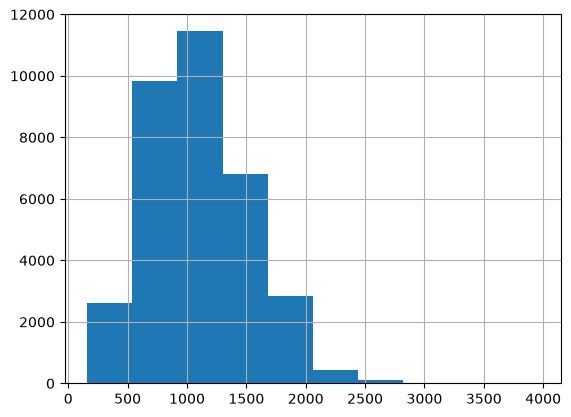

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df_orders = df.groupby('order_id')[['total_price']].sum()
df_orders['total_price'].hist(bins=10)

C:\Users\91460\AppData\Local\Temp\ipykernel_10416\4154941335.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(category_sales, x='category', y='total_price', palette='Reds', ax=ax)


<Axes: xlabel='category', ylabel='total_price'>

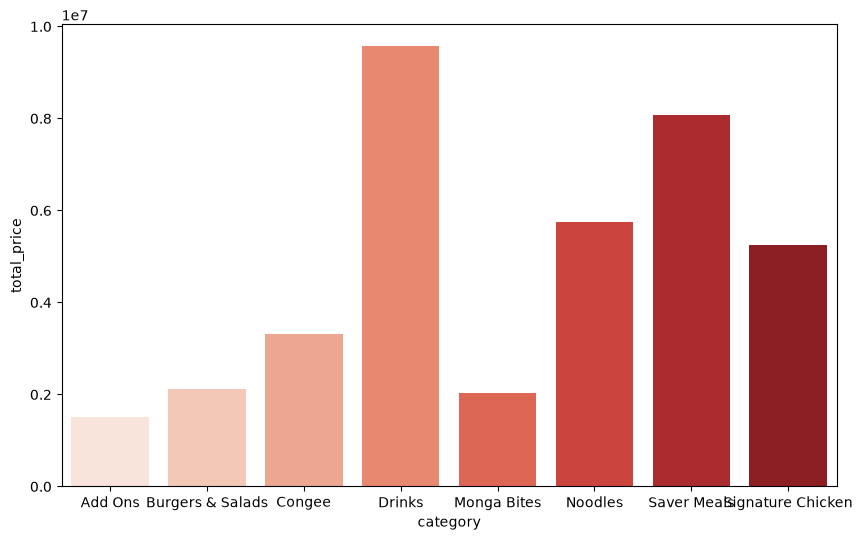

In [48]:
category_sales = df.groupby('category')[['total_price']].sum()

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(category_sales, x='category', y='total_price', palette='Reds', ax=ax)

C:\Users\91460\AppData\Local\Temp\ipykernel_10416\2675976973.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(store_sales, x='store_name', y='total_price', ax=ax, palette="Reds")


Text(0.5, 0, 'Store')

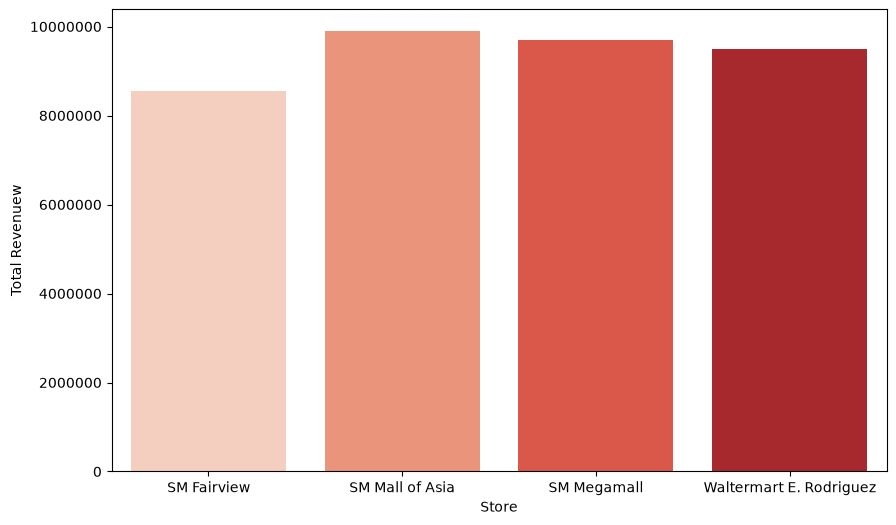

In [49]:
store_sales = df.groupby('store_name')[['total_price']].sum()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(store_sales, x='store_name', y='total_price', ax=ax, palette="Reds")

ax.ticklabel_format(style='plain', axis='y')
ax.set_ylabel(ylabel='Total Revenuew')
ax.set_xlabel(xlabel='Store')